# One-to-One Skew-GRAM : plus long chemin (D,G)-consistant par embeddings de nœuds et décodeur guidé

**Projet universitaire — Deep Learning, NLP & Optimisation Combinatoire sur les Graphes**

---

## Résumé

Ce notebook implémente **One-to-One Skew-GRAM**, une approche d'apprentissage de représentation de nœuds qui transpose le principe du **Skip-Gram** (Mikolov et al., 2013) et de **DeepWalk/node2vec** (Perozzi et al., 2014 ; Grover & Leskovec, 2016) à un problème d'optimisation combinatoire NP-difficile sur deux graphes couplés partageant le même ensemble de sommets $V$ : un DAG orienté `D` et un graphe non orienté `G`. On cherche le **plus long chemin (D,G)-consistant**, c'est-à-dire un chemin de `D` dont les sommets induisent un sous-graphe connexe dans `G`.

### Pipeline en 4 phases

1. **Phase 1 — Marches aléatoires orientées sur `D` et sous-échantillonnage des hubs** : corpus de marches (les « phrases ») et réduction de l'influence des nœuds fréquents (formule word2vec).
2. **Phase 2 — Embeddings Skew-GRAM** : matrices $\mathbf{V}_{in}, \mathbf{V}_{out} \in \mathbb{R}^{N \times d}$ apprises par Negative Sampling avec **négatifs structurels** (tirés parmi les non-successeurs de chaque nœud dans `D`).
3. **Phase 3 — Décodeur guidé** : marches Monte-Carlo dans `D` guidées par un score qui combine le lookahead exact du plus long chemin restant (programmation dynamique, $O(|V|+|A|)$), la similarité d'embedding $\mathbf{v}_{in,u}^\top \mathbf{v}_{out,v}$ et un bonus de connexité dans `G`.
4. **Phase 4 — Extraction exacte par Union-Find** : une fenêtre glissante extrait le plus long sous-chemin contigu dont les sommets sont connexes dans `G`.

Chaque instance est traitée avec la même graine (`SEED = 42`), ré-initialisée au début de l'instance : le résultat d'une instance ne dépend pas des autres.

In [1]:
import os
import re
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
DATA_DIR = "data/raw"
FIGURES_DIR = "figures"
RESULTS_DIR = "results"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Hyperparamètres (conformes à main.tex, annexe des hyperparamètres)
NUM_WALKS = 40
WALK_LENGTH = 30
WINDOW = 3
EMBED_DIM = 32
EPOCHS = 8
K_NEG = 5
LR = 0.01
DECODE_TAU = 0.5
DECODE_TAU_LF = 1.5
DECODE_BETA = 0.3
DECODE_GAMMA = 6.0
DECODE_WALKS = 30000

# Couleurs des figures : Skew-GRAM (bleu) et ILP2 (orange)
SKEW_COLOR = "#2a78d6"
ILP2_COLOR = "#eb6834"
plt.rcParams["font.size"] = 10


def set_seed(seed=SEED):
    """Ré-initialise toutes les sources d'aléa (appelée au début de chaque instance)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def save_figure(fig, name):
    fig.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, name), dpi=300, bbox_inches="tight")
    plt.show()

## 1. Chargement et contrôle des données

Chaque instance `data/raw/100_<k>/` contient `graphD.txt` (chargé comme graphe **orienté** `D`), `graphG.txt` (chargé comme graphe **non orienté** `G`) et `solution.txt` (résultat du solveur exact ILP2). **Toutes** les instances complètes de `data/raw/` sont utilisées : pour en ajouter, il suffit de les télécharger (`python scripts/download_instances.py --target N`) et de ré-exécuter le notebook.

`G` n'a pas besoin d'être connexe : le problème n'exige que la connexité du sous-graphe induit par le chemin. Trois contrôles sont faits sur chaque instance : `D` est un DAG, `D` et `G` ont les mêmes sommets, et la solution ILP2 (quand elle existe) est bien (D,G)-consistante.

In [2]:
def load_graph(path, directed):
    G = nx.DiGraph() if directed else nx.Graph()
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith("N:"):
                G.add_nodes_from(range(1, int(line[2:]) + 1))
            elif line and not line.startswith("P:"):
                a, b = map(int, line.split("-"))
                G.add_edge(a, b)
    return G


def load_solution(path):
    text = open(path).read()
    t_match = re.search(r"Execution time:\s*([\d.]+)", text)
    exec_time = float(t_match.group(1)) if t_match else None
    if "No solution found" in text:
        return {"status": "not_found", "path": None, "length": None, "time": exec_time}
    path_match = re.search(r"Path\s*:\s*\[([^\]]*)\]", text)
    len_match = re.search(r"Path length:\s*(\d+)", text)
    p = [int(x) for x in path_match.group(1).split(",")] if path_match else None
    length = int(len_match.group(1)) if len_match else (len(p) if p else None)
    return {"status": "found", "path": p, "length": length, "time": exec_time}


def list_instances(data_dir=DATA_DIR):
    """Toutes les instances complètes de data_dir (3 fichiers non vides), triées numériquement."""
    def is_complete(name):
        paths = [os.path.join(data_dir, name, f) for f in ("graphD.txt", "graphG.txt", "solution.txt")]
        return all(os.path.isfile(p) and os.path.getsize(p) > 0 for p in paths)
    return sorted(filter(is_complete, os.listdir(data_dir)), key=lambda s: int(s.split("_")[1]))


def is_DG_consistent(path, D, G):
    """Vrai si `path` est un chemin de D dont les sommets induisent un sous-graphe connexe dans G."""
    in_D = all(D.has_edge(a, b) for a, b in zip(path, path[1:]))
    return bool(path) and in_D and nx.is_connected(G.subgraph(path))

In [3]:
INSTANCES = list_instances()
GRAPHS, SOLUTIONS = {}, {}
for inst in INSTANCES:
    d = os.path.join(DATA_DIR, inst)
    D = load_graph(os.path.join(d, "graphD.txt"), directed=True)
    G = load_graph(os.path.join(d, "graphG.txt"), directed=False)
    sol = load_solution(os.path.join(d, "solution.txt"))
    assert nx.is_directed_acyclic_graph(D), inst
    assert set(D) == set(G), inst
    assert sol["path"] is None or is_DG_consistent(sol["path"], D, G), inst
    GRAPHS[inst], SOLUTIONS[inst] = (D, G), sol

n_found = sum(s["status"] == "found" for s in SOLUTIONS.values())
n_G_disconnected = sum(not nx.is_connected(G) for _, G in GRAPHS.values())
print(f"{len(INSTANCES)} instances chargées : {n_found} avec une solution ILP2, "
      f"{n_G_disconnected} avec un G non connexe (gardées).")

200 instances chargées : 197 avec une solution ILP2, 5 avec un G non connexe (gardées).


## 2. Phase 1 : marches aléatoires sur `D`, sous-échantillonnage des hubs et couples Skip-Gram

Les marches suivent les arcs sortants de `D`. Le sous-échantillonnage des hubs (formule word2vec) réduit la domination des nœuds fréquents. Une fenêtre glissante de taille `WINDOW` produit ensuite les couples (centre, contexte).

In [4]:
def generate_walks(D, rng, num_walks=NUM_WALKS, walk_length=WALK_LENGTH):
    """`num_walks` marches depuis chaque nœud non puits, en suivant les arcs sortants de D."""
    nodes = [v for v in D.nodes() if D.out_degree(v) > 0]
    walks = []
    for _ in range(num_walks):
        rng.shuffle(nodes)
        for start in nodes:
            walk = [start]
            while len(walk) < walk_length:
                succs = list(D.successors(walk[-1]))
                if not succs:
                    break
                walk.append(rng.choice(succs))
            walks.append(walk)
    return walks


def node_frequencies(walks, n_nodes):
    return np.bincount([v for w in walks for v in w], minlength=n_nodes + 1)


def subsample_hubs(walks, freq, rng, t=1e-3):
    """Garde chaque occurrence de v avec la probabilité word2vec min(1, sqrt(t/f) + t/f)."""
    f = freq / freq.sum()
    keep_prob = np.ones_like(f)
    seen = f > 0
    keep_prob[seen] = np.minimum(1.0, np.sqrt(t / f[seen]) + t / f[seen])
    new_walks = []
    for w in walks:
        kept = [v for v in w if rng.random() < keep_prob[v]]
        if len(kept) >= 2:
            new_walks.append(kept)
    return new_walks


def build_pairs(walks, window=WINDOW):
    pairs = []
    for w in walks:
        for i, center in enumerate(w):
            for j in range(max(0, i - window), min(len(w), i + window + 1)):
                if j != i:
                    pairs.append((center, w[j]))
    return pairs

## 3. Phase 2 : modèle One-to-One Skew-GRAM et entraînement

Deux matrices d'embeddings $\mathbf{V}_{in}, \mathbf{V}_{out} \in \mathbb{R}^{N\times d}$, perte de Negative Sampling avec **échantillonnage négatif structurel** (les exemples négatifs sont tirés parmi les non-successeurs dans `D`) :

$$\mathcal{L}(c,o,n_{1:K}) = -\log\sigma(\mathbf v_{in,c}^\top \mathbf v_{out,o}) - \sum_{k=1}^K \log\sigma(-\mathbf v_{in,c}^\top \mathbf v_{out,n_k})$$

In [5]:
class SkewGram(nn.Module):
    def __init__(self, n_nodes, dim=EMBED_DIM):
        super().__init__()
        # Les nœuds sont numérotés de 1 à N : la ligne 0 n'est pas utilisée
        self.in_emb = nn.Embedding(n_nodes + 1, dim)
        self.out_emb = nn.Embedding(n_nodes + 1, dim)
        nn.init.uniform_(self.in_emb.weight, -0.5 / dim, 0.5 / dim)
        nn.init.uniform_(self.out_emb.weight, -0.5 / dim, 0.5 / dim)

    def forward(self, centers, contexts, negatives):
        v_c = self.in_emb(centers)
        v_o = self.out_emb(contexts)
        v_n = self.out_emb(negatives)
        pos_loss = F.logsigmoid(torch.sum(v_c * v_o, dim=1))
        neg_score = torch.bmm(v_n, v_c.unsqueeze(2)).squeeze(2)
        neg_loss = F.logsigmoid(-neg_score).sum(dim=1)
        return -(pos_loss + neg_loss).mean()


def structural_negative_table(D):
    """Pour chaque nœud u : les candidats négatifs sont les nœuds qui ne sont pas ses successeurs."""
    nodes_set = set(D.nodes())
    table = {}
    for u in D.nodes():
        non_succs = list(nodes_set - set(D.successors(u)) - {u})
        table[u] = non_succs or list(nodes_set - {u})
    return table


def sample_structural_negatives(centers, neg_table, rng, k=K_NEG):
    return np.array([[rng.choice(neg_table[c]) for _ in range(k)] for c in centers], dtype=np.int64)


def train_skewgram(D, pairs, epochs=EPOCHS, batch_size=128, lr=LR, seed=SEED):
    model = SkewGram(D.number_of_nodes())
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    neg_table = structural_negative_table(D)
    rng = random.Random(seed)

    centers = np.array([c for c, _ in pairs], dtype=np.int64)
    contexts = np.array([o for _, o in pairs], dtype=np.int64)
    order = np.arange(len(pairs))
    history = []
    for _ in range(epochs):
        np.random.shuffle(order)
        losses = []
        for start in range(0, len(order), batch_size):
            idx = order[start:start + batch_size]
            negs = sample_structural_negatives(centers[idx], neg_table, rng)
            loss = model(torch.from_numpy(centers[idx]), torch.from_numpy(contexts[idx]), torch.from_numpy(negs))
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())
        history.append(np.mean(losses))
    return model, history

## 4. Phases 3 & 4 : décodeur guidé et extraction exacte par Union-Find

**Phase 3 — Décodeur guidé.** Une passe topologique inverse sur `D` calcule exactement $\mathrm{lf}(v)$, la longueur du plus long chemin partant de $v$. À chaque pas, le successeur $v$ du nœud courant $u$ est tiré selon une softmax du score
$$S(u,v) = \frac{\mathrm{lf}(v)}{\tau_{lf}} + \beta \frac{\operatorname{sim}(u,v)}{\tau} + \log(\gamma) \cdot \mathbb{I}[v \text{ est adjacent dans } G \text{ à un nœud du chemin}]$$
où $\operatorname{sim}(u,v) = \mathbf{v}_{in,u}^\top \mathbf{v}_{out,v}$ (produit scalaire). Les nœuds déjà visités sont masqués (contrainte One-to-One). On répète `DECODE_WALKS` marches depuis des nœuds de départ aléatoires.

**Phase 4 — Extraction du sous-chemin (D,G)-consistant.** Tout sous-chemin contigu d'un chemin de `D` est encore un chemin de `D` : il ne reste qu'à imposer la connexité dans `G`. Pour chaque début $i$, la fenêtre $[i, j]$ grandit et un Union-Find compte les composantes connexes ; on garde la plus longue fenêtre à une seule composante. Chaque nouveau sommet est comparé à toute la fenêtre, d'où une complexité $O(L^3\,\alpha(L))$ pour un chemin de longueur $L$ — négligeable ici car un chemin candidat ne peut pas être plus long que le plus long chemin de `D` ($L \le 24$ nœuds sur les instances évaluées).

In [6]:
def compute_dag_lookahead(D):
    """lf(v) = longueur du plus long chemin partant de v dans D (passe topologique inverse, O(|V|+|A|))."""
    lookahead = {}
    for v in reversed(list(nx.topological_sort(D))):
        lookahead[v] = max((1 + lookahead[w] for w in D.successors(v)), default=0)
    return lookahead


def longest_connected_subpath(path, G):
    """Phase 4 : plus long sous-chemin contigu de `path` dont les sommets sont connexes dans G."""
    best_i, best_j = 0, 0
    for i in range(len(path)):
        parent = {}

        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x

        n_components = 0
        for j in range(i, len(path)):
            v = path[j]
            parent[v] = v
            n_components += 1
            for u in path[i:j]:
                if G.has_edge(u, v) and find(u) != find(v):
                    parent[find(u)] = find(v)
                    n_components -= 1
            if n_components == 1 and j - i > best_j - best_i:
                best_i, best_j = i, j
    return path[best_i:best_j + 1]


def decode_skewgram_path(D, G, model, tau=DECODE_TAU, beta=DECODE_BETA, gamma=DECODE_GAMMA,
                         tau_lf=DECODE_TAU_LF, n_walks=DECODE_WALKS, seed=SEED):
    """Phases 3 & 4 : marches guidées dans D, puis extraction du plus long sous-chemin connexe dans G."""
    lookahead = compute_dag_lookahead(D)
    v_in = model.in_emb.weight.detach().numpy()
    v_out = model.out_emb.weight.detach().numpy()

    # Partie du score S(u, v) qui ne dépend pas du chemin : lookahead + similarité d'embedding
    base_scores = {}
    for u in D.nodes():
        succs = np.array(list(D.successors(u)))
        if len(succs):
            lf = np.array([lookahead[v] for v in succs]) / tau_lf
            sim = v_out[succs] @ v_in[u] / tau
            base_scores[u] = (succs, lf + beta * sim)

    log_gamma = np.log(gamma)
    rng = random.Random(seed)
    nodes = list(D.nodes())
    best = []
    for _ in range(n_walks):
        u = rng.choice(nodes)
        path, visited = [u], {u}
        while u in base_scores:
            succs, base = base_scores[u]
            free = [i for i, v in enumerate(succs) if v not in visited]
            if not free:
                break
            candidates = succs[free]
            # Bonus log(γ) si le candidat est adjacent dans G à un nœud déjà dans le chemin
            g_bonus = np.array([log_gamma if any(G.has_edge(x, v) for x in path) else 0.0 for v in candidates])
            scores = base[free] + g_bonus
            probs = np.exp(scores - scores.max())
            probs /= probs.sum()
            u = int(np.random.choice(candidates, p=probs))
            path.append(u)
            visited.add(u)

        # Inutile d'extraire si le chemin brut n'est pas plus long que le meilleur actuel
        if len(path) > len(best):
            sub = longest_connected_subpath(path, G)
            if len(sub) > len(best):
                best = sub
    return best

## 5. Pipeline complet sur une instance

`run_pipeline` enchaîne les 4 phases. Elle ré-initialise les graines au début : le résultat d'une instance ne dépend ni de l'ordre de traitement ni des autres instances. La même fonction sert à la démonstration (§6) et à l'évaluation (§7).

In [7]:
def run_pipeline(D, G, seed=SEED):
    """Phases 1 → 4 sur une instance. Retourne (chemin, modèle, historique de la perte)."""
    set_seed(seed)  # chaque instance repart du même état → reproductible
    walks = generate_walks(D, rng=random.Random(seed))
    freq = node_frequencies(walks, D.number_of_nodes())
    walks = subsample_hubs(walks, freq, rng=random.Random(seed))
    model, history = train_skewgram(D, build_pairs(walks), seed=seed)
    path = decode_skewgram_path(D, G, model, seed=seed)
    return path, model, history

## 6. Démonstration sur une instance représentative

Même pipeline (et donc même résultat) que pour cette instance dans l'évaluation du §7.

Instance 100_14 : chemin de longueur 12 en 5.65s (optimum ILP2 : 12)
Chemin : [23, 86, 38, 37, 62, 16, 79, 98, 55, 12, 88, 11]
(D,G)-consistant : True


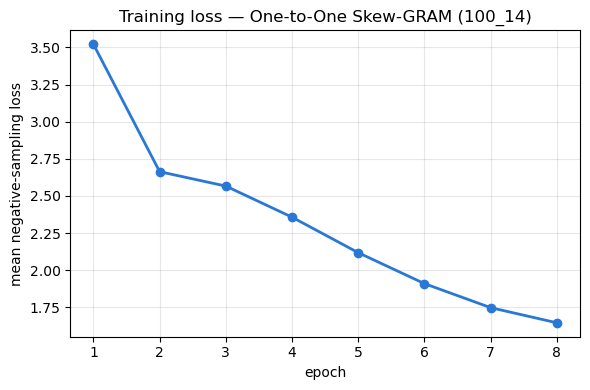

In [8]:
REPRESENTATIVE = "100_14"
D_demo, G_demo = GRAPHS[REPRESENTATIVE]

t0 = time.time()
path_demo, model_demo, history_demo = run_pipeline(D_demo, G_demo)
print(f"Instance {REPRESENTATIVE} : chemin de longueur {len(path_demo)} en {time.time() - t0:.2f}s "
      f"(optimum ILP2 : {SOLUTIONS[REPRESENTATIVE]['length']})")
print("Chemin :", path_demo)
print("(D,G)-consistant :", is_DG_consistent(path_demo, D_demo, G_demo))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, EPOCHS + 1), history_demo, marker="o", color=SKEW_COLOR, lw=2)
ax.set_title(f"Training loss — One-to-One Skew-GRAM ({REPRESENTATIVE})")
ax.set_xlabel("epoch")
ax.set_ylabel("mean negative-sampling loss")
ax.grid(True, alpha=0.3)
save_figure(fig, "01_training_curve.png")

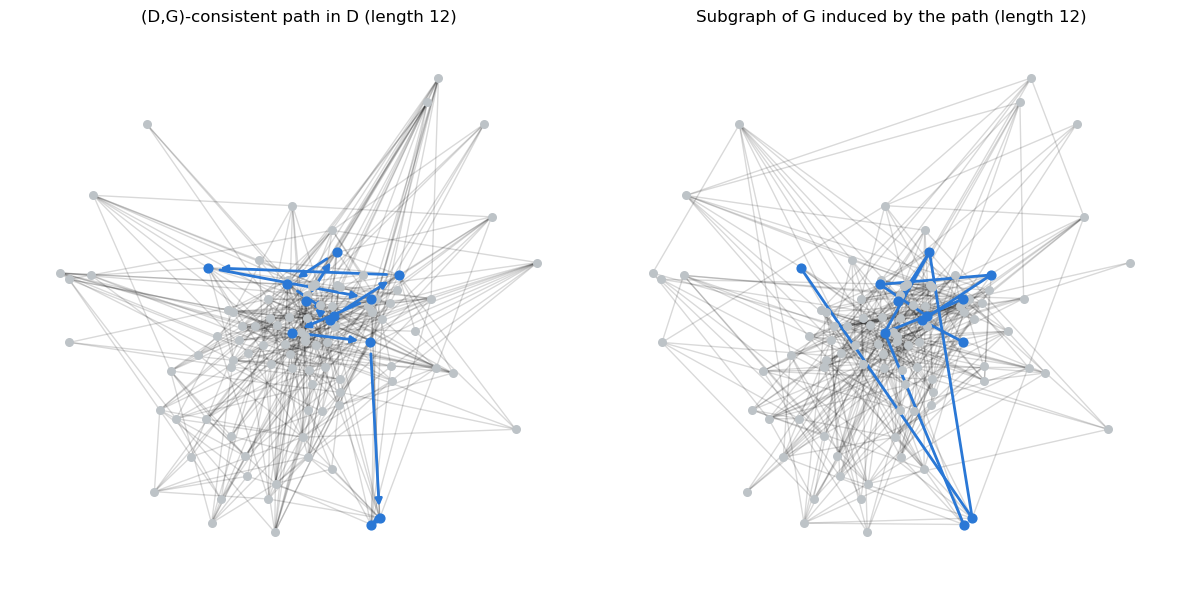

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
pos = nx.spring_layout(D_demo, seed=SEED)
path_set = set(path_demo)
path_edges = list(zip(path_demo, path_demo[1:]))
induced_edges = [(u, v) for u, v in G_demo.edges() if u in path_set and v in path_set]

panels = [
    (axes[0], D_demo, path_edges, f"(D,G)-consistent path in D (length {len(path_demo)})"),
    (axes[1], G_demo, induced_edges, f"Subgraph of G induced by the path (length {len(path_demo)})"),
]
for ax, graph, highlighted_edges, title in panels:
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=30, node_color="#bdc3c7")
    nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.15, arrows=False)
    nx.draw_networkx_nodes(graph, pos, nodelist=path_demo, ax=ax, node_size=40, node_color=SKEW_COLOR)
    nx.draw_networkx_edges(graph, pos, edgelist=highlighted_edges, ax=ax, edge_color=SKEW_COLOR, width=2)
    ax.set_title(title)
    ax.axis("off")
save_figure(fig, "02_graph_topology_paths.png")

## 7. Évaluation sur toutes les instances

Pour chaque instance : `run_pipeline` (marches → sous-échantillonnage → couples Skip-Gram → entraînement → décodage guidé → extraction Union-Find), vérification que le chemin retourné est (D,G)-consistant, puis comparaison à la référence ILP2.

Les instances sans solution ILP2 sont gardées dans les résultats mais exclues des comparaisons (écart, accélération). Les temps ILP2 proviennent des fichiers `solution.txt` et ont été mesurés sur une autre machine : l'accélération est **indicative**.

In [10]:
rows = []
for inst in INSTANCES:
    D, G = GRAPHS[inst]
    sol = SOLUTIONS[inst]
    t0 = time.time()
    path, _, _ = run_pipeline(D, G)
    elapsed = time.time() - t0
    assert is_DG_consistent(path, D, G), inst
    rows.append({
        "instance": inst,
        "ilp2_status": sol["status"],
        "ilp2_length": sol["length"],
        "ilp2_time_s": sol["time"],
        "skewgram_length": len(path),
        "skewgram_time_s": elapsed,
        "skewgram_path": path,
    })
    print(f"{inst}: ILP2={sol['length']} | Skew-GRAM={len(path)} | {elapsed:.2f}s")

df_results = pd.DataFrame(rows)
df_results["gap_pct_vs_ilp2"] = 100 * (df_results["skewgram_length"] - df_results["ilp2_length"]) / df_results["ilp2_length"]
df_results["speedup_vs_ilp2"] = df_results["ilp2_time_s"] / df_results["skewgram_time_s"]
df_results.to_csv(os.path.join(RESULTS_DIR, "per_instance_results.csv"), index=False)

100_1: ILP2=None | Skew-GRAM=7 | 4.13s


100_2: ILP2=None | Skew-GRAM=11 | 3.59s


100_3: ILP2=13 | Skew-GRAM=13 | 9.17s


100_4: ILP2=11 | Skew-GRAM=11 | 3.91s


100_5: ILP2=8 | Skew-GRAM=8 | 6.06s


...

100_478: ILP2=10 | Skew-GRAM=6 | 4.35s


100_489: ILP2=7 | Skew-GRAM=7 | 5.58s


100_491: ILP2=7 | Skew-GRAM=7 | 10.12s


100_527: ILP2=11 | Skew-GRAM=4 | 7.51s


100_563: ILP2=None | Skew-GRAM=9 | 4.86s


In [11]:
found = df_results[df_results["ilp2_status"] == "found"]
summary = {
    "n_instances": len(df_results),
    "n_ilp2_found": len(found),
    "mean_ilp2_length": found["ilp2_length"].mean(),
    "mean_skewgram_length": found["skewgram_length"].mean(),  # même sous-ensemble qu'ILP2
    "mean_gap_pct_vs_ilp2": found["gap_pct_vs_ilp2"].mean(),
    "n_matches_ilp2": int((found["skewgram_length"] == found["ilp2_length"]).sum()),
    "n_above_ilp2": int((found["skewgram_length"] > found["ilp2_length"]).sum()),  # ILP2 est exact : doit valoir 0
    "mean_skewgram_time_s": found["skewgram_time_s"].mean(),
    "mean_ilp2_time_s": found["ilp2_time_s"].mean(),
    "median_speedup_vs_ilp2": found["speedup_vs_ilp2"].median(),
}
df_summary = pd.DataFrame([summary])
df_summary.to_csv(os.path.join(RESULTS_DIR, "summary.csv"), index=False)
df_summary.T

,0
n_instances,200.000000
n_ilp2_found,197.000000
mean_ilp2_length,10.020305
mean_skewgram_length,9.593909
mean_gap_pct_vs_ilp2,-4.014942
n_matches_ilp2,146.000000
n_above_ilp2,0.000000
mean_skewgram_time_s,5.417315
mean_ilp2_time_s,29.892966
median_speedup_vs_ilp2,5.219135


## 8. Visualisation des résultats

À gauche : nombre de nœuds qui manquent à Skew-GRAM par rapport à l'optimum ILP2 (0 = optimum atteint). À droite : compromis temps / qualité.

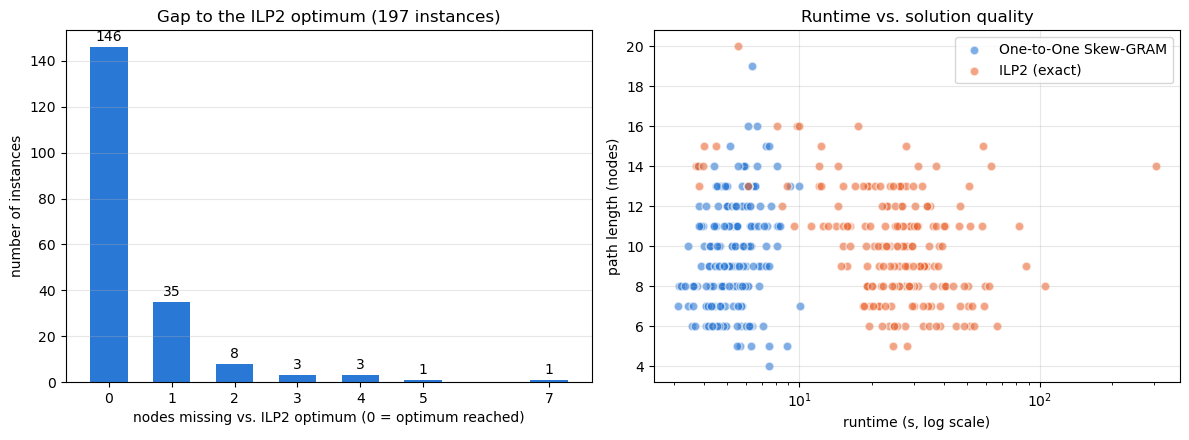

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

missing = (found["ilp2_length"] - found["skewgram_length"]).astype(int).value_counts().sort_index()
bars = axes[0].bar(missing.index, missing.values, color=SKEW_COLOR, width=0.6)
axes[0].bar_label(bars, padding=2)
axes[0].set_xticks(missing.index)
axes[0].set_title(f"Gap to the ILP2 optimum ({len(found)} instances)")
axes[0].set_xlabel("nodes missing vs. ILP2 optimum (0 = optimum reached)")
axes[0].set_ylabel("number of instances")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].scatter(found["skewgram_time_s"], found["skewgram_length"], color=SKEW_COLOR, s=40,
                alpha=0.6, edgecolor="white", label="One-to-One Skew-GRAM")
axes[1].scatter(found["ilp2_time_s"], found["ilp2_length"], color=ILP2_COLOR, s=40,
                alpha=0.6, edgecolor="white", label="ILP2 (exact)")
axes[1].set_xscale("log")
axes[1].set_title("Runtime vs. solution quality")
axes[1].set_xlabel("runtime (s, log scale)")
axes[1].set_ylabel("path length (nodes)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
save_figure(fig, "03_evaluation_comparison.png")

## 9. Discussion

**Qualité.** Sur les 197 instances avec un optimum ILP2 connu, Skew-GRAM obtient en moyenne 9,59 nœuds contre 10,02 pour ILP2 (écart moyen de −4,0 %). Il atteint l'optimum sur 146 instances (74 %) et reste à au plus un nœud de l'optimum sur 181 instances (92 %). Il ne dépasse jamais ILP2 (`n_above_ilp2 = 0`), ce qui est cohérent avec l'exactitude d'ILP2, et chacun des 200 chemins retournés est (D,G)-consistant (vérifié par `assert`).

**Temps.** Environ 5,4 s par instance contre 29,9 s pour ILP2, soit une accélération médiane d'environ 5×. Ces temps sont indicatifs : ceux d'ILP2 ont été mesurés sur une autre machine, ceux de Skew-GRAM sur une machine partagée. Le décodage (30 000 marches) représente la plus grande partie du temps de calcul.

**Limites.** L'heuristique reste stochastique : sur quelques instances (par exemple `100_527` : 4 nœuds contre 11 pour ILP2), les marches guidées n'atteignent pas la bonne région de `D`. Le seuil de sous-échantillonnage des hubs ($t = 10^{-3}$, repris de word2vec) et la longueur maximale des marches (30, alors que les marches sont beaucoup plus courtes en pratique) n'ont pas fait l'objet d'une étude de sensibilité.

## 10. Conclusion

Ce notebook implémente One-to-One Skew-GRAM de bout en bout : apprentissage Skip-Gram sur des marches orientées de `D` avec négatifs structurels, décodeur stochastique guidé par le lookahead exact du DAG, la similarité d'embedding et la connexité dans `G`, puis extraction exacte par Union-Find du plus long chemin (D,G)-consistant. Évaluée de manière reproductible sur 200 instances, la méthode atteint l'optimum ILP2 sur la majorité des instances pour un temps de calcul environ 5 fois plus faible.